### Figure 5. Trial by trial analysis. Test the hypothesis that theta sequences extending towards the end removes extra graph paths.
Oct 25, 2025

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [12]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (figure4_master, save_remote_animal_figure4,
            load_remote_animal_figure4, remote_theta_count_per_day, long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindTheta

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

In [450]:
from spyglass.shijiegu.changeOfMind_deltat import long_theta_delta_t, find_transition_interval, return_trial_deltat

In [382]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}
transition_to_investigate = {}
other_transition_to_investigate = {}

In [383]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

transition_to_investigate[animal] = [(2,1),(3,4)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)], (3,4):[(3,1),(3,2)]}

In [436]:
animal = "lewis"
animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

transition_to_investigate[animal] = [(4,3)]
other_transition_to_investigate[animal] = {(4,3): [(4,1)]}

In [400]:
animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

transition_to_investigate[animal] = [(2,1)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)]}

In [511]:
animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
transition_to_investigate[animal] = [(4,3)]
other_transition_to_investigate[animal] = {(4,3): [(4,2)]}
seq_animals[animal] = 'rev2'

In [ ]:
animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

transition_to_investigate[animal] = [(2,1)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)]}
seq_animals[animal] = 'seq2'


In [453]:
use_1d = 1
proportion = 0.1

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure5/'

def return_save_name(animal, d1, d2):
    save_name = f'{animal.lower()}_{d1}_{d2}_figure5'
    return save_name

In [456]:
def delta_t_animal(animal, list_of_days, transition_final, transition_initial):
    
    # find long theta trials
    _, _2, dates2session_trial = long_theta_count_per_day(
            animal, list_of_days, 0.1, 5, 5, 1)

    """
    dates2session_trial looks like:
        {'20240105': 
        [('02_Rev2Session1', 20),
         ('02_Rev2Session1', 25),
         ('02_Rev2Session1', 50),
         ('02_Rev2Session1', 62),
         ('02_Rev2Session1', 70),
    """

    data = {}
    (data["pre_post_control"], data["pre_post_com"], data["pre_post_theta"],
     data["pre_post_control_others"],
     data["pre_post_com_others"], data["pre_post_theta_others"]) = long_theta_delta_t(animal,
                       dates2session_trial,
                       transition_final, transition_initial)
    # save data
    data["transition_final"] = transition_final
    data["transition_initial"] = transition_initial
    data["dates2session_trial"] = dates2session_trial
    
    save_name = return_save_name(animal, list_of_days[0], list_of_days[-1])
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        
    return 1

### Make data

In [512]:
success = {}
for animal in ["klein"]:
    success[animal] = delta_t_animal(
        animal, list_of_days_animals[animal],
        transition_to_investigate[animal], other_transition_to_investigate[animal])

[2025-10-27 22:51:51,996][WARNING]: Skipped checksum for file with hash: 7dc653d3-716c-1006-6f9e-a97d4391fd7f, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_T3OEH3NRFS.nwb


klein20231101_.nwb


[2025-10-27 22:52:01,328][WARNING]: Skipped checksum for file with hash: 89d15458-0f8f-61e8-d1a9-93226c35e106, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_260WQY1J5H.nwb
[2025-10-27 22:52:10,146][WARNING]: Skipped checksum for file with hash: 1ba56d31-5342-6865-9898-dae1a3159ada, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_07WK1VR39D.nwb
[2025-10-27 22:52:18,905][WARNING]: Skipped checksum for file with hash: 1fc34d62-05f6-66e0-e269-ac4ffe88eac9, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_PGWQK2PZCZ.nwb
[2025-10-27 22:52:27,732][WARNING]: Skipped checksum for file with hash: 752997b3-a7ed-63ba-e93c-be729636e9fb, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_6RT16A8Z7N.nwb
[2025-10-27 22:52:36,597][WARNING]: Skipped checksum for file with hash: 9cf4f491-1458-c116-a13a-8bac1e206520, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_953IPNBDQY.nwb
[2025-10-27 22:52:45,260][WARNING]: Skipped checksum for file with hash: a5

klein20231102_.nwb


[2025-10-27 22:52:53,991][WARNING]: Skipped checksum for file with hash: c99a4e38-72e0-0d38-30b2-893a112ebae6, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_0605MSYX6O.nwb
[2025-10-27 22:53:02,672][WARNING]: Skipped checksum for file with hash: c9a570b2-b046-dbce-42c5-991db0d59c76, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_25WQVF9CQG.nwb
[2025-10-27 22:53:11,426][WARNING]: Skipped checksum for file with hash: 24bea014-b41c-5065-1a65-f99239050868, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_1SZU3OH9Q0.nwb
[2025-10-27 22:53:20,186][WARNING]: Skipped checksum for file with hash: a775e9cc-d7cd-841d-efb3-cc7ee57f5892, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_15MABO0TIC.nwb
[2025-10-27 22:53:28,917][WARNING]: Skipped checksum for file with hash: 7c37600b-09ae-f6ec-b8ad-19bceaa824d9, and path: /stelmo/nwb/analysis/klein20231103/klein20231103_SZYWP0H3ZR.nwb


...

klein20231109_.nwb


[2025-10-27 22:57:42,382][WARNING]: Skipped checksum for file with hash: aa4b88bf-b38e-d714-fc74-61b4c7ed796f, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_UQFCFP9AV5.nwb
[2025-10-27 22:57:51,039][WARNING]: Skipped checksum for file with hash: c77a2ac7-6fef-1819-ac7c-5f7c6915f509, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_XHHZCB6PSI.nwb
[2025-10-27 22:57:59,743][WARNING]: Skipped checksum for file with hash: 9d9ad985-8b25-45fa-380d-d631d40a1f75, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_87YVLHTJ2Z.nwb
[2025-10-27 22:58:08,436][WARNING]: Skipped checksum for file with hash: 86b81795-0200-db1b-f059-9cb460915ca9, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_2XAZJM0QNS.nwb
[2025-10-27 22:58:17,108][WARNING]: Skipped checksum for file with hash: b5e240c7-f1ac-37c6-5e1c-86f066ddffdb, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_6H2H9L7RQ6.nwb


klein20231111_.nwb


[2025-10-27 22:58:25,788][WARNING]: Skipped checksum for file with hash: cd021f6c-59fa-eea0-7848-f52b0ac191fa, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_VRPVHTI1X0.nwb
[2025-10-27 22:58:34,495][WARNING]: Skipped checksum for file with hash: 6f0a2a55-7cf5-769c-b18b-16585017c4b2, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_30MMHG7OV3.nwb
[2025-10-27 22:58:43,148][WARNING]: Skipped checksum for file with hash: d50b346f-ad42-bf72-7ce9-c39ae03821db, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_FXY6K59G0V.nwb
[2025-10-27 22:58:51,857][WARNING]: Skipped checksum for file with hash: ec4fc7ed-f1ea-8a34-e5fb-6b4a4fdb0327, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_RR46U6QBXA.nwb
[2025-10-27 22:59:00,592][WARNING]: Skipped checksum for file with hash: 7dc653d3-716c-1006-6f9e-a97d4391fd7f, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_T3OEH3NRFS.nwb
[2025-10-27 22:59:09,277][WARNING]: Skipped checksum for file with hash: 89

data saved to /stelmo/shijie/change_of_mind_analysis/figure5/klein_20231101_20231111_figure5.pkl


### Load data

In [567]:
animal = "molly"

list_of_days = list_of_days_animals[animal]
seq = seq_animals[animal] = 'seq2'

{(2, 1): [(2, 3), (2, 4)], (3, 4): [(3, 1), (3, 2)]}

In [568]:
save_name = return_save_name(animal, list_of_days[0], list_of_days[-1])
file_path = output_folder + save_name + '.pkl'
with open(file_path, 'rb') as file:
    print("data loaded " + file_path)
    loaded_data = pickle.load(file)

data loaded /stelmo/shijie/change_of_mind_analysis/figure5/molly_20220416_20220420_figure5.pkl


In [569]:
pre_post_com = loaded_data["pre_post_com"]
pre_post_theta = loaded_data["pre_post_theta"]
pre_post_control = loaded_data["pre_post_control"]

pre_post_com_others = loaded_data["pre_post_com_others"]
pre_post_theta_others = loaded_data["pre_post_theta_others"]
pre_post_control_others = loaded_data["pre_post_control_others"]

transition_final = loaded_data["transition_final"]
transition_initial = loaded_data["transition_initial"]
dates2session_trial = loaded_data["dates2session_trial"]

In [570]:
#pre_post_control

#### 1. scatter plot

In [571]:
from scipy.stats import mannwhitneyu

diff_com -0.8
diff_control -0.13513513513513514
diff_theta nan
diff_control -0.13513513513513514
diff_com -0.8
diff_control -0.7037037037037037
diff_theta -1.0
diff_control -0.7037037037037037


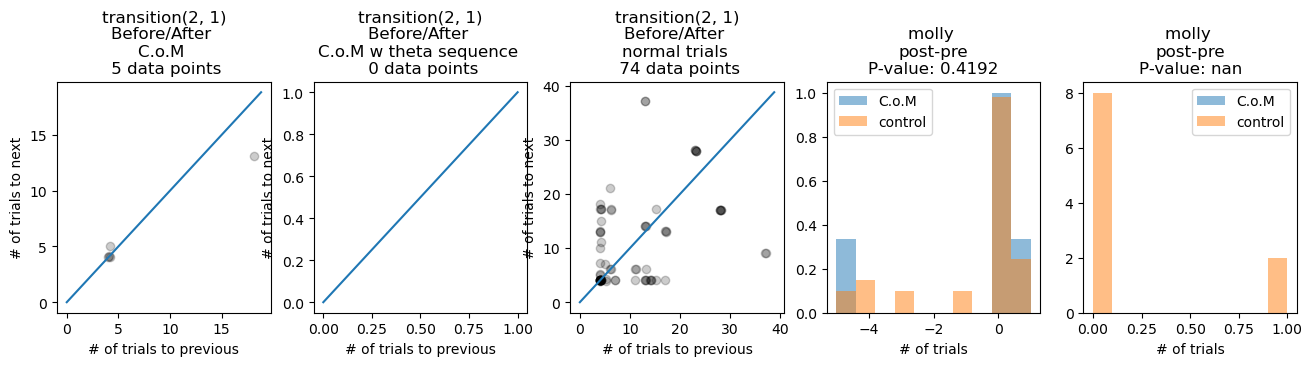

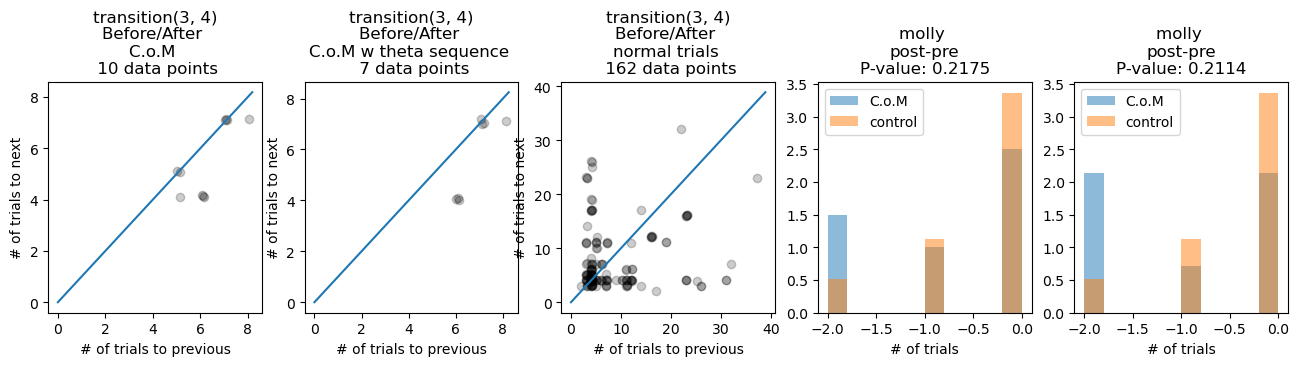

In [572]:
#figure_path = '/Documents/spyglass/notebooks/Change of Mind Analysis/figure5/'
figure_path = ''

for transition in transition_final:
    fig, axes = plt.subplots(1,5,figsize = (16,3))

    pre_post_com_ = pre_post_com[transition]
    pre_post_theta_ = pre_post_theta[transition]
    pre_post_control_ = pre_post_control[transition]
    
    for pp in pre_post_com_:
        axes[0].scatter(pp[0] + np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    for pp in pre_post_theta_:
        axes[1].scatter(pp[0] + np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    for pp in pre_post_control_:
        axes[2].scatter(pp[0]+ np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    axes[0].plot([0,axes[0].get_xlim()[1]],[0,axes[0].get_xlim()[1]])
    axes[1].plot([0,axes[1].get_xlim()[1]],[0,axes[1].get_xlim()[1]])
    axes[2].plot([0,axes[2].get_xlim()[1]],[0,axes[2].get_xlim()[1]])
    axes[0].set_xlabel("# of trials to previous")
    axes[0].set_ylabel("# of trials to next")
    axes[1].set_xlabel("# of trials to previous")
    axes[1].set_ylabel("# of trials to next")
    axes[2].set_xlabel("# of trials to previous")
    axes[2].set_ylabel("# of trials to next")
    
    axes[0].set_title(f"transition{transition}\nBefore/After \nC.o.M \n {len(pre_post_com_)} data points")
    axes[1].set_title(f"transition{transition}\nBefore/After \nC.o.M w theta sequence \n {len(pre_post_theta_)} data points")
    axes[2].set_title(f"transition{transition}\nBefore/After \nnormal trials \n {len(pre_post_control_)} data points")


    diff_com = [pp[1] - pp[0] for pp in pre_post_com_]
    diff_control = [pp[1] - pp[0] for pp in pre_post_control_]

    # Perform the Mann-Whitney U test (Wilcoxon Rank-Sum test)
    print("diff_com", np.mean(diff_com))
    print("diff_control", np.mean(diff_control))
    
    statistic, p_value = mannwhitneyu(diff_com, diff_control, alternative='less')
    
    histogram = axes[3].hist(diff_com, alpha = 0.5, density = True, label = "C.o.M")
    axes[3].hist(diff_control, alpha = 0.5, density = True, bins = histogram[1], label = "control")
    axes[3].set_title(f"{animal} \npost-pre\nP-value: {np.round(p_value, 4)}")
    axes[3].set_xlabel("# of trials")
    axes[3].legend()

    ### theta set
    diff_theta = [pp[1] - pp[0] for pp in pre_post_theta_]
    diff_control = [pp[1] - pp[0] for pp in pre_post_control_]

    # Perform the Mann-Whitney U test (Wilcoxon Rank-Sum test)
    print("diff_theta", np.mean(diff_theta))
    print("diff_control", np.mean(diff_control))
    
    statistic, p_value = mannwhitneyu(diff_theta, diff_control, alternative='less')
    
    histogram = axes[4].hist(diff_theta, alpha = 0.5, density = True, label = "C.o.M")
    axes[4].hist(diff_control, alpha = 0.5, density = True, bins = histogram[1], label = "control")
    axes[4].set_title(f"{animal} \npost-pre\nP-value: {np.round(p_value, 4)}")
    axes[4].set_xlabel("# of trials")
    axes[4].legend()

    figure_path_pdf = os.path.join(figure_path,f"{animal}_transition{transition[0]}{transition[1]}_delta_t.pdf")
    figure_path_png = os.path.join(figure_path,f"{animal}_transition{transition[0]}{transition[1]}_delta_t.png")

    plt.savefig(figure_path_pdf, dpi=200, bbox_inches='tight', transparent=True)
    plt.savefig(figure_path_png, dpi=200, bbox_inches='tight', transparent=True)

diff_theta 0.5
diff_control 0.5
diff_com 0.5
diff_control 0.5
diff_theta 0.42857142857142855
diff_control 0.18811881188118812
diff_com 0.0
diff_control 0.18811881188118812
diff_theta 6.0
diff_control 1.2317073170731707
diff_com -5.619047619047619
diff_control 1.2317073170731707
diff_theta -1.0
diff_control -2.1029411764705883
diff_com 3.6
diff_control -2.1029411764705883


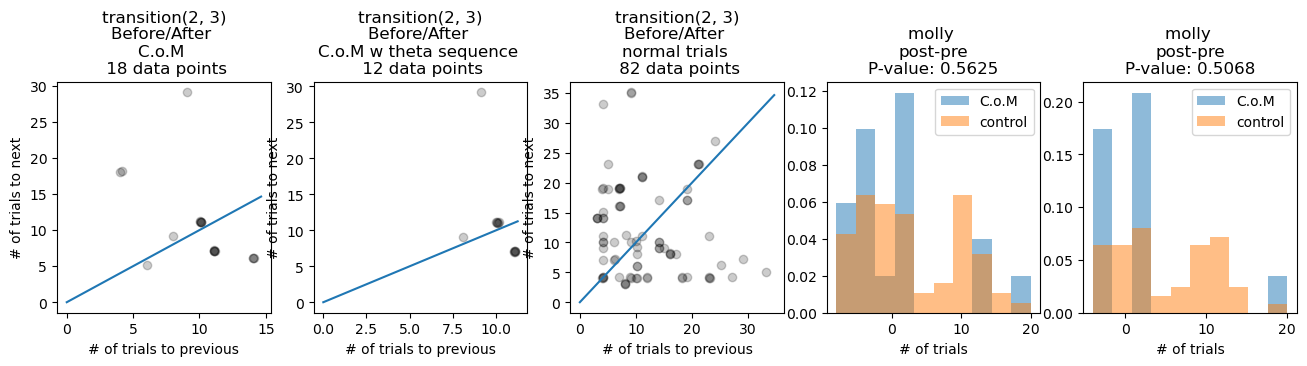

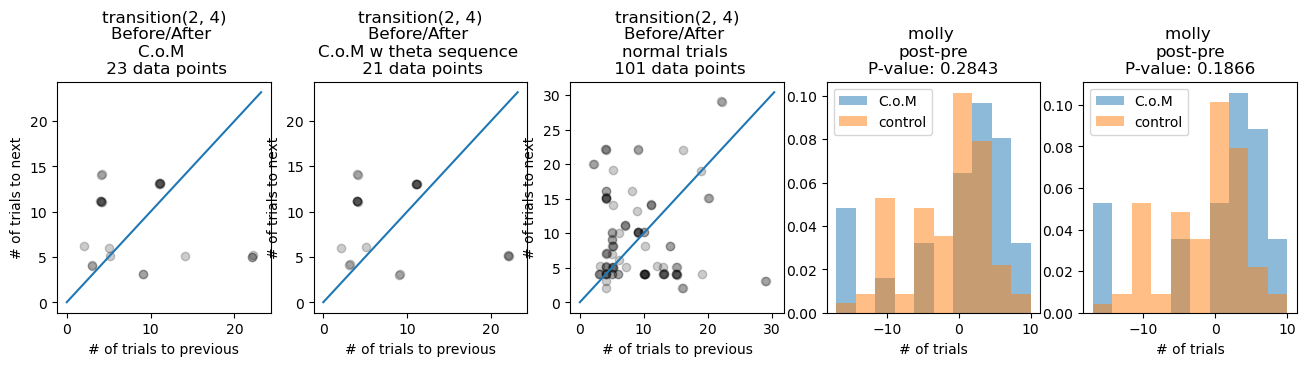

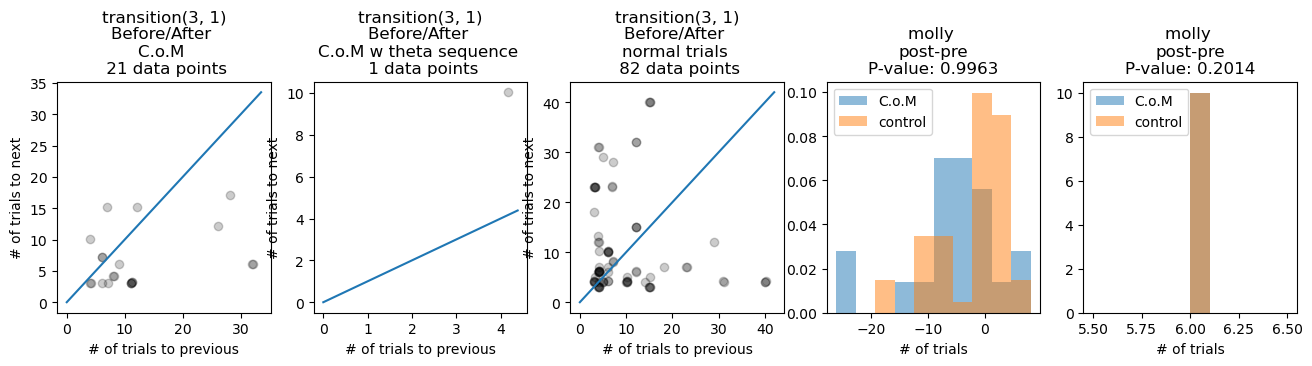

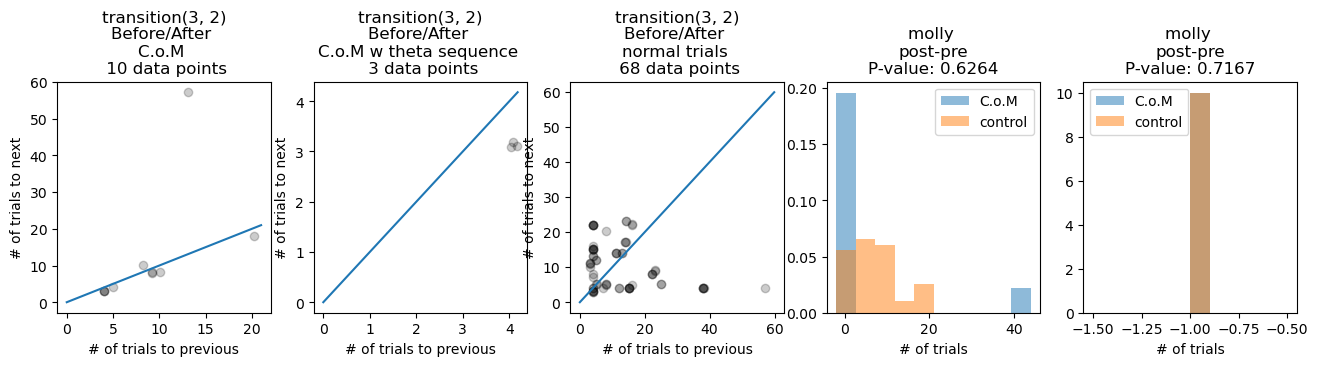

In [573]:
#figure_path = '/Documents/spyglass/notebooks/Change of Mind Analysis/figure5/'
figure_path = ''

transitions_initial = []
for key in transition_initial:
    for transition in transition_initial[key]:
        transitions_initial.append(transition)
        
for transition in transitions_initial:

    fig, axes = plt.subplots(1,5,figsize = (16,3))

    pre_post_com_ = pre_post_com_others[transition]
    pre_post_theta_ = pre_post_theta_others[transition]
    pre_post_control_ = pre_post_control_others[transition]
    
    for pp in pre_post_com_:
        axes[0].scatter(pp[0] + np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    for pp in pre_post_theta_:
        axes[1].scatter(pp[0] + np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    for pp in pre_post_control_:
        axes[2].scatter(pp[0]+ np.random.rand() * 0.2,pp[1]+ np.random.rand() * 0.2,color = 'k',alpha = 0.2)
    axes[0].plot([0,axes[0].get_xlim()[1]],[0,axes[0].get_xlim()[1]])
    axes[1].plot([0,axes[1].get_xlim()[1]],[0,axes[1].get_xlim()[1]])
    axes[2].plot([0,axes[2].get_xlim()[1]],[0,axes[2].get_xlim()[1]])
    axes[0].set_xlabel("# of trials to previous")
    axes[0].set_ylabel("# of trials to next")
    axes[1].set_xlabel("# of trials to previous")
    axes[1].set_ylabel("# of trials to next")
    axes[2].set_xlabel("# of trials to previous")
    axes[2].set_ylabel("# of trials to next")
    
    axes[0].set_title(f"transition{transition}\nBefore/After \nC.o.M \n {len(pre_post_com_)} data points")
    axes[1].set_title(f"transition{transition}\nBefore/After \nC.o.M w theta sequence \n {len(pre_post_theta_)} data points")
    axes[2].set_title(f"transition{transition}\nBefore/After \nnormal trials \n {len(pre_post_control_)} data points")


    ### theta set
    diff_theta = [pp[1] - pp[0] for pp in pre_post_theta_]
    diff_control = [pp[1] - pp[0] for pp in pre_post_control_]

    # Perform the Mann-Whitney U test (Wilcoxon Rank-Sum test)
    print("diff_theta", np.mean(diff_theta))
    print("diff_control", np.mean(diff_control))
    
    statistic, p_value = mannwhitneyu(diff_theta, diff_control, alternative='greater')
    
    histogram = axes[4].hist(diff_theta, alpha = 0.5, density = True, label = "C.o.M")
    axes[4].hist(diff_control, alpha = 0.5, density = True, bins = histogram[1], label = "control")
    axes[4].set_title(f"{animal} \npost-pre\nP-value: {np.round(p_value, 4)}")
    axes[4].set_xlabel("# of trials")
    axes[4].legend()


    ### all com set
    diff_com = [pp[1] - pp[0] for pp in pre_post_com_]
    diff_control = [pp[1] - pp[0] for pp in pre_post_control_]

    # Perform the Mann-Whitney U test (Wilcoxon Rank-Sum test)
    print("diff_com", np.mean(diff_com))
    print("diff_control", np.mean(diff_control))
    
    statistic, p_value = mannwhitneyu(diff_com, diff_control, alternative='greater')
    
    histogram = axes[3].hist(diff_com, alpha = 0.5, density = True, label = "C.o.M")
    axes[3].hist(diff_control, alpha = 0.5, density = True, bins = histogram[1], label = "control")
    axes[3].set_title(f"{animal} \npost-pre\nP-value: {np.round(p_value, 4)}")
    axes[3].set_xlabel("# of trials")
    axes[3].legend()

    figure_path_pdf = os.path.join(figure_path,f"{animal}_transition{transition[0]}{transition[1]}_delta_t.pdf")
    figure_path_png = os.path.join(figure_path,f"{animal}_transition{transition[0]}{transition[1]}_delta_t.png")

    plt.savefig(figure_path_pdf, dpi=200, bbox_inches='tight', transparent=True)
    plt.savefig(figure_path_png, dpi=200, bbox_inches='tight', transparent=True)


In [519]:
### 

In [574]:
t0 = np.array([2,3,10,12])
t1 = np.array([4,8,11])
t0_, t1_, delta_t = return_trial_deltat(t0, t1)

In [575]:
t0_

array([ 3, 10])

In [576]:
t1_

array([ 4, 11])